# Contextualização

![](https://media-exp1.licdn.com/dms/image/C4E12AQGbAM-_eriLMw/article-cover_image-shrink_720_1280/0/1632916005843?e=1669248000&v=beta&t=Jrz7HA1m-Qbhm08T89CaeaESJnsodVxsetVxJHVsVKM)

[Fonte da imagem](https://www.linkedin.com/pulse/supervised-vs-unsupervised-learning-whats-difference-smriti-saini/)

**Aprendizado não-supervisionado (unsupervised learning)**

No aprendizado não supervisionado, do qual **clustering** faz parte, **não há variável resposta**, e entre seus objetivos estão o tratamento, exploração e diagnóstico dos dados (exemplo: encontrar padrões).

**Exemplos:**
- **Clustering:** identificar e agrupar observações similares.
- **Dimensionality reduction:** reduzir a quantidade de dimensões (variáveis).

**Quantos algoritmos não-supervisionados temos?**

- Clustering: [https://scikit-learn.org/stable/modules/clustering.html](https://scikit-learn.org/stable/modules/clustering.html)
- Dimentionality reduction: [https://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition)

**Classifique como tarefa supervisionada ou não-supervisionada:**

1. Segmentação de clientes para entendermos melhor diferentes perfis: ________
2. Classificação de clientes em churn e não-churn: ________
3. Agrupamento de produtos similares entre si: ________
4. Redução da dimensionalidade dos dados: ________
5. Previsão da probabilidade de um cliente contratar o serviço: ________

<details>
  <summary><b>Respostas</b></summary>
  <ol type="1">
  <li><b>unsupervised learning</b></li>
  <li>supervised learning</li>
  <li><b>unsupervised learning</b></li>
  <li><b>unsupervised learning</b></li>
  <li>supervised learning</li>
  </ol>
</details>

# Setup

In [5]:
# %%capture
# %pip install kmodes
# !pip install yellowbrick
# !pip install ipywidgets

In [6]:
# Data wrangling
import numpy as np
import pandas as pd

# Dataviz
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer, InterclusterDistance, kelbow_visualizer, silhouette_visualizer

## -- Machine learning -- ##
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.cluster import k_means, dbscan, mean_shift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from kmodes.kmodes import KModes            # clustering categorical data
from kmodes.kprototypes import KPrototypes  # clustering mixed data

# Didatic purposes
import string
from ipywidgets import interact

In [7]:
import matplotlib.pyplot as plt


In [8]:
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
sns.set_theme(
    context='talk',
    style='ticks',
    font_scale=.8,
    palette='tab10',
    rc={
        'figure.figsize': (12,8),
        'axes.grid': True,
        'grid.alpha': .2,
        'axes.titlesize': 'x-large',
        'axes.titleweight': 'bold',
        'axes.titlepad': 20,
    }
)

scatter_kwargs = dict(palette='viridis', alpha=0.8, linewidth=0)

# K-means

Apps de simulação:
- [Versão em português (streamlit)](https://cmcouto-silva-kmeans-app-pt-streamlit-app-tyl62y.streamlitapp.com/)
- [Versão em português (dash)](https://kmeans-animation-pt.herokuapp.com/)
- [Versão em inglês](https://cmcouto-silva-kmeans-app-en-streamlit-app-v886a2.streamlitapp.com/)

**Requerimentos:**
- Dados numéricos contínuos
- Dados na mesma escala
- Pré-determinação do número de grupos (k)

**Vantagens:**
- Simples
- Eficiente
- Escalável para uma grande quantidade de dados

**Desvantagens:**
- Sensível a outliers
- Pré-determinação do número de grupos (k)
- Não adequado para dados categóricos (mesmo com one-hot encoding)
- Agrupa apenas pontos próximos entre si

Por quê não utilizar dummies no algoritmo? Vide:
- [https://www.ibm.com/support/pages/clustering-binary-data-k-means-should-be-avoided](https://www.ibm.com/support/pages/clustering-binary-data-k-means-should-be-avoided)
- Livro: Practical Statistics for Data Scientists (Peter Bruce et al., 2020)
- Statistical foruns

## Simulated Data

In [9]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(5E3), n_features=2, centers=4, cluster_std=.8, random_state=42)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,3.851236,1.745846
1,-7.873424,-7.780579
2,3.961772,1.451499
3,-7.762175,-6.223667
4,-9.208354,7.633667


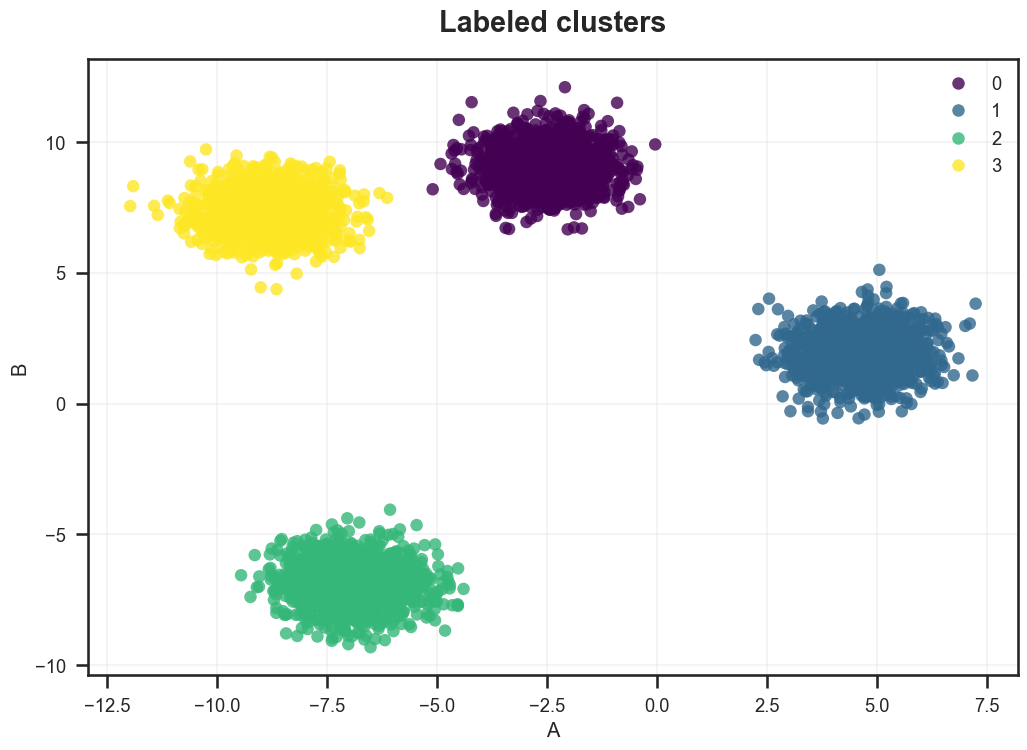

In [10]:
# Visualize simulated clusters
sns.scatterplot(data=df, x='A', y='B', hue=y, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

## Distinct APIs for K-means

No sklearn, podemos utilizar algoritmos de clusterização através classes ou funções (vide [este link](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster)).

In [11]:
# Usando função
k_means(X, n_clusters=4, random_state=42)


(array([[ 4.62826191,  1.94726375],
        [-2.50138934,  9.05833956],
        [-6.89143046, -6.91208453],
        [-8.83866084,  7.33763741]]),
 array([0, 2, 0, ..., 0, 1, 0], shape=(5000,), dtype=int32),
 6438.463928042347)

In [12]:
centroids, labels, intertia = k_means(X, n_clusters=4)

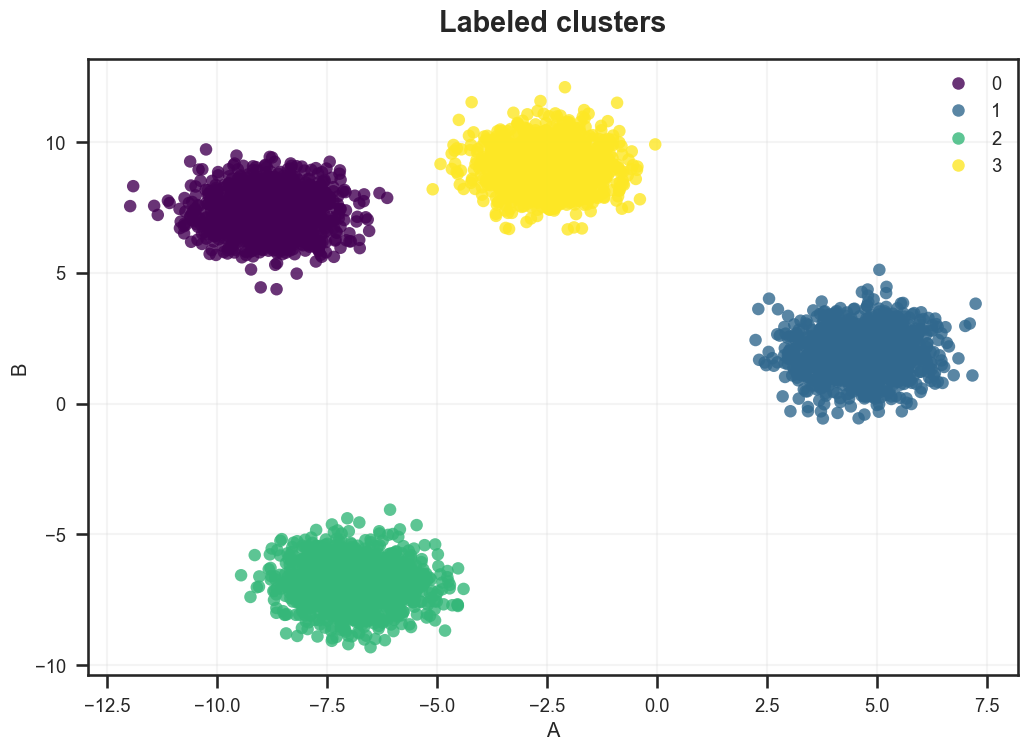

In [13]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

## Distinct APIs for K-means

No sklearn, podemos utilizar algoritmos de clusterização através classes ou funções (vide [este link](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster)).

In [14]:
# Usando função
centroids, labels, intertia = k_means(X, n_clusters=4)

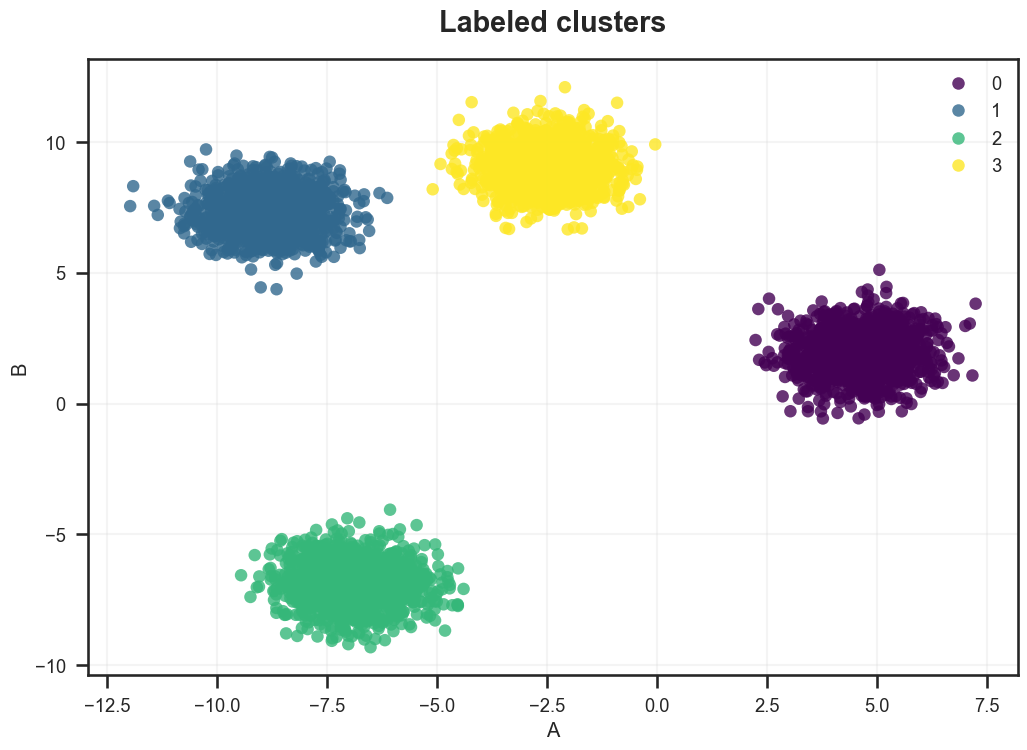

In [15]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

In [16]:
# Using KMeans
model = KMeans(n_clusters=4, random_state=42)
model.fit(X)

centroids = model.cluster_centers_
labels = model.labels_
inertia = model.inertia_

In [17]:
centroids

array([[ 4.62826191,  1.94726375],
       [-2.50138934,  9.05833956],
       [-6.89143046, -6.91208453],
       [-8.83866084,  7.33763741]])

In [18]:
labels

array([0, 2, 0, ..., 0, 1, 0], shape=(5000,), dtype=int32)

In [19]:
inertia

6438.463928042344

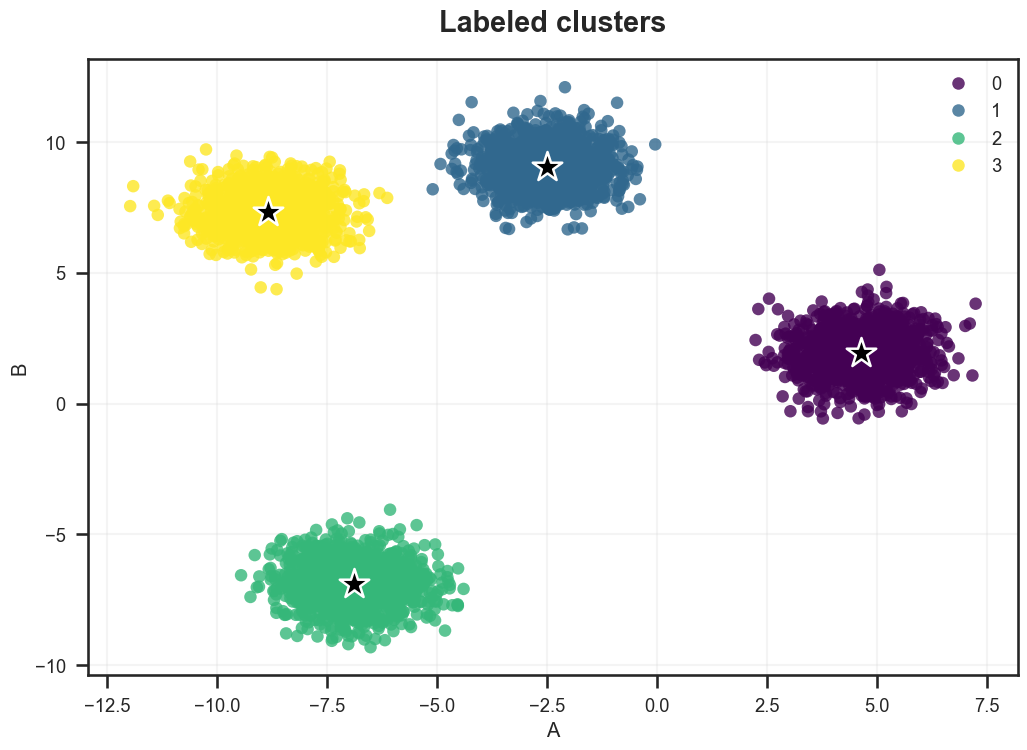

In [20]:
ax = sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], marker='*', s=500, color='black', ax=ax)

plt.title('Labeled clusters')
plt.show()

## Model evaluation

Uma boa clusterização vai produzir:
- Alta similaridade intra-cluster
- Pouca similaridade entre clusters

Métricas:
- WCSS
- Silhouette
- Davies Bouldin (`intracluster / intercluster`)
- Calinski Harabasz (`soma_intercluster / soma_intracluster`)

Exemplo de aplicação:

In [21]:
# sklearn metrics
silhouette_score(X, labels)
davies_bouldin_score(X, labels)
calinski_harabasz_score(X, labels)

84652.53492291895

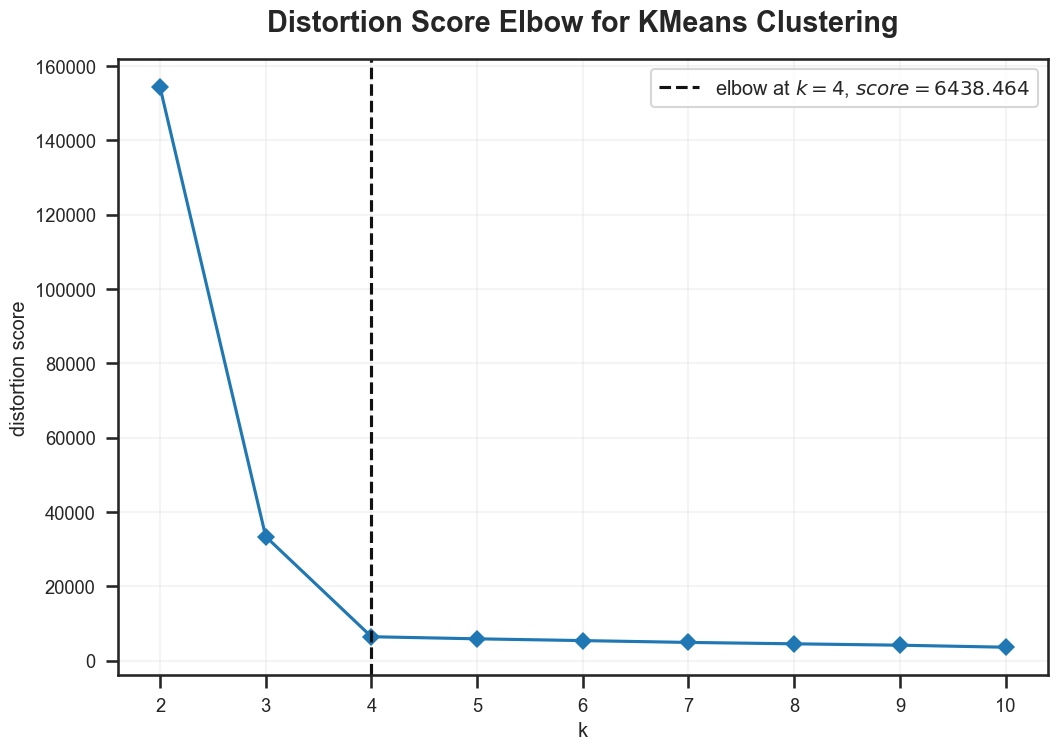

,estimator,KMeans(n_clusters=10)
,ax,<Axes: title=...ortion score'>
,k,10
,metric,'distortion'
,distance_metric,'euclidean'
,timings,False
,locate_elbow,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [22]:
# kelbow_visualizer
kelbow_visualizer(KMeans(), X, k=10, timings=False)

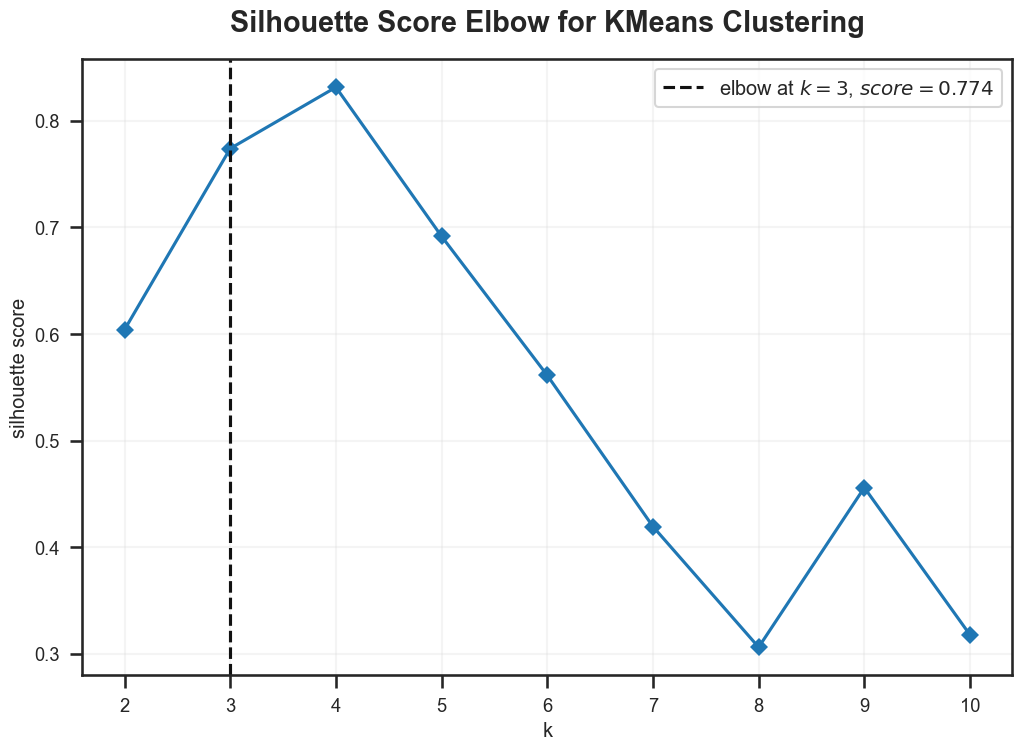

,estimator,KMeans(n_clusters=10)
,ax,<Axes: title=...ouette score'>
,k,10
,metric,'silhouette'
,distance_metric,'euclidean'
,timings,False
,locate_elbow,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [23]:
# kelbow_visualizer
kelbow_visualizer(KMeans(), X, k=10, timings=False, metric='silhouette')

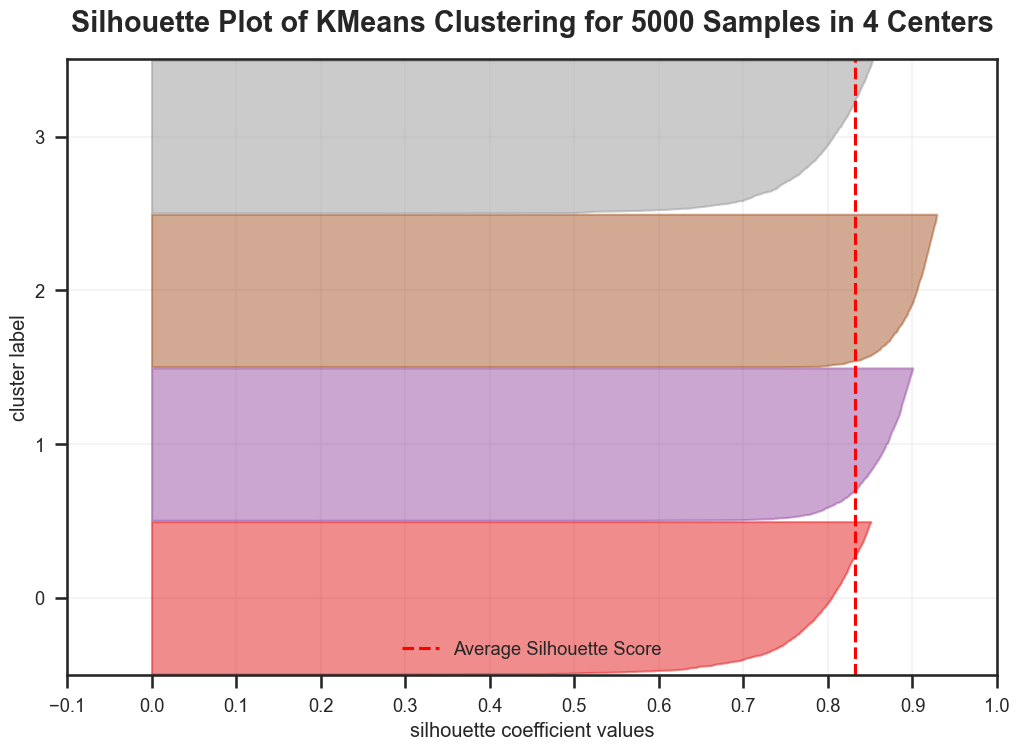

,estimator,KMeans(n_clusters=4)
,ax,<Axes: title=...luster label'>
,colors,None
,is_fitted,'auto'
,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None


In [24]:
# silhouette_visualizer
silhouette_visualizer(KMeans(n_clusters=4), X)

Testando distintos agrupamentos:

In [25]:
# Create list of dictionaries

cluster_metrics = silhouette_score, davies_bouldin_score, calinski_harabasz_score
cluster_metrics_results = []

for k in range(2,11):
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(X)
  cluster_results_dict = {'k': k}
  cluster_results_dict['inertia'] = model.inertia_
  for metric in cluster_metrics:
    cluster_results_dict[metric.__name__] = metric(X, labels)
  cluster_metrics_results.append(cluster_results_dict)

cluster_metrics_results

[{'k': 2,
  'inertia': 165384.20786354315,
  'silhouette_score': 0.5627158249398301,
  'davies_bouldin_score': 0.9214456613549218,
  'calinski_harabasz_score': 5087.188327323066},
 {'k': 3,
  'inertia': 33389.60517411427,
  'silhouette_score': 0.7740756211383696,
  'davies_bouldin_score': 0.3399165510572917,
  'calinski_harabasz_score': 22473.30116848767},
 {'k': 4,
  'inertia': 6438.463928042345,
  'silhouette_score': 0.8316196523510032,
  'davies_bouldin_score': 0.23564938235726685,
  'calinski_harabasz_score': 84652.53492291896},
 {'k': 5,
  'inertia': 5919.370570507666,
  'silhouette_score': 0.7080051283228401,
  'davies_bouldin_score': 0.6277175906021945,
  'calinski_harabasz_score': 69157.34943268735},
 {'k': 6,
  'inertia': 5576.195729120338,
  'silhouette_score': 0.7121551277594544,
  'davies_bouldin_score': 0.5781981574067308,
  'calinski_harabasz_score': 58779.16284932036},
 {'k': 7,
  'inertia': 5058.397200751363,
  'silhouette_score': 0.5720216268358549,
  'davies_bouldin_s

In [26]:
# Create dataframe
pd.DataFrame(cluster_metrics_results).set_index('k').style.background_gradient()

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,165384.207864,0.562716,0.921446,5087.188327
3,33389.605174,0.774076,0.339917,22473.301168
4,6438.463928,0.831620,0.235649,84652.534923
5,5919.370571,0.708005,0.627718,69157.349433
6,5576.195729,0.712155,0.578198,58779.162849
7,5058.397201,0.572022,0.832762,54071.462166
8,4573.216787,0.445434,1.021812,51334.764198
9,4054.901376,0.308635,1.173030,50731.096659
10,3712.413946,0.313237,1.088184,49297.275734


In [27]:
# Style dataframe
(
  pd.DataFrame(cluster_metrics_results)
  .set_index('k')
  .style.background_gradient(cmap='Oranges', subset='inertia')
  .highlight_max(subset=['silhouette_score','calinski_harabasz_score'])
  .highlight_min(subset='davies_bouldin_score')
)

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,165384.207864,0.562716,0.921446,5087.188327
3,33389.605174,0.774076,0.339917,22473.301168
4,6438.463928,0.831620,0.235649,84652.534923
5,5919.370571,0.708005,0.627718,69157.349433
6,5576.195729,0.712155,0.578198,58779.162849
7,5058.397201,0.572022,0.832762,54071.462166
8,4573.216787,0.445434,1.021812,51334.764198
9,4054.901376,0.308635,1.173030,50731.096659
10,3712.413946,0.313237,1.088184,49297.275734


Repetindo procedimento acima com dados simulados aleatórios:

In [28]:
# X_random with numpy
X_random = np.random.rand(*X.shape)
X_random

array([[0.76530256, 0.34532393],
       [0.84124185, 0.4895032 ],
       [0.41863532, 0.96895096],
       ...,
       [0.30730143, 0.6512899 ],
       [0.6223929 , 0.05242047],
       [0.60520929, 0.13294322]], shape=(5000, 2))

<Axes: >

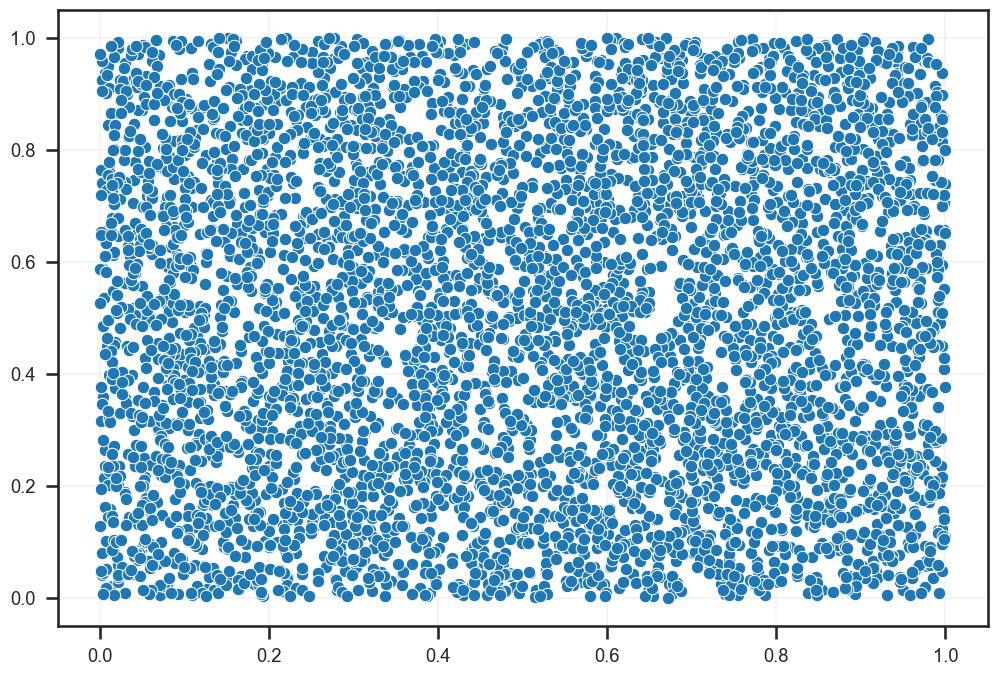

In [29]:
sns.scatterplot(x=X_random[:,0], y=X_random[:,1])

In [30]:
cluster_metrics = silhouette_score, davies_bouldin_score, calinski_harabasz_score
cluster_metrics_results = []

for k in range(2,11):
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(X_random)
  cluster_results_dict = {'k': k}
  cluster_results_dict['inertia'] = model.inertia_
  for metric in cluster_metrics:
    cluster_results_dict[metric.__name__] = metric(X_random, labels)
  cluster_metrics_results.append(cluster_results_dict)

pd.DataFrame(cluster_metrics_results).set_index('k').style.background_gradient()

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,521.756624,0.351516,1.194256,2970.237237
3,334.566767,0.369098,0.881926,3713.666431
4,207.064098,0.410839,0.769014,5024.722838
5,174.295415,0.392171,0.869308,4711.242446
6,149.678672,0.351233,0.968231,4551.972502
7,127.937157,0.350580,0.927996,4578.594488
8,108.546071,0.364076,0.806703,4751.943893
9,92.003783,0.364195,0.788439,5016.838720
10,84.593196,0.353731,0.842431,4897.780099


In [31]:
# Style dataframe
(
  pd.DataFrame(cluster_metrics_results)
  .set_index('k')
  .style.background_gradient(cmap='Oranges', subset='inertia')
  .highlight_max(subset=['silhouette_score','calinski_harabasz_score'])
  .highlight_min(subset='davies_bouldin_score')
)

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,521.756624,0.351516,1.194256,2970.237237
3,334.566767,0.369098,0.881926,3713.666431
4,207.064098,0.410839,0.769014,5024.722838
5,174.295415,0.392171,0.869308,4711.242446
6,149.678672,0.351233,0.968231,4551.972502
7,127.937157,0.350580,0.927996,4578.594488
8,108.546071,0.364076,0.806703,4751.943893
9,92.003783,0.364195,0.788439,5016.838720
10,84.593196,0.353731,0.842431,4897.780099


Comparando de forma interativa:

In [32]:
@interact(k=(2,11), data=['X','X_random'])
def plot_kmeans(k, data):
  data = X if data=='X' else X_random
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(data)
  sns.scatterplot(x=data[:,0], y=data[:,1], hue=labels, **scatter_kwargs)

interactive(children=(IntSlider(value=6, description='k', max=11, min=2), Dropdown(description='data', options…

## High dimensional data

In [33]:
# Simulate clusters with high dimensional data
X_dim,y_dim = datasets.make_blobs(n_samples=int(1E3), n_features=10, centers=4, cluster_std=.8, random_state=42)
df_dim = pd.DataFrame(X_dim, columns=list(string.ascii_uppercase[:X_dim.shape[1]]))
df_dim.head()

,A,B,C,D,E,F,G,H,I,J
0,-9.118025,9.893988,5.119799,-5.678834,-6.738298,-6.938922,-2.834473,-0.027815,-2.006201,-4.114861
1,-1.836683,8.492187,4.282932,0.461537,-7.241472,-8.819213,-10.105450,7.931855,2.650940,4.501818
2,-10.044176,9.661804,5.435114,-5.152754,-6.696456,-7.235965,-4.275165,1.500848,-1.789368,-3.888654
3,2.597853,-6.913228,-9.678478,8.263492,10.699874,6.475314,-3.821517,-8.246473,3.918380,-0.972761
4,1.504777,-6.902774,-7.494919,8.113709,9.442878,7.363971,-4.958099,-7.731378,3.042843,-1.600657


In [34]:
# Apply PCA
pca = PCA()
pca_components = pca.fit_transform(df_dim)

df_pca = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,15.073142,-4.316705,-6.739933,0.461229,-0.403220,-1.716382,0.082211,-0.994268,0.409410,-0.074076
1,14.843483,7.136611,6.223981,-2.304937,-0.067046,-0.595796,-0.847741,-0.669064,0.428498,-0.298020
2,15.839582,-3.759468,-5.679969,0.131592,0.330700,-1.194786,-0.683229,-0.312434,-0.909602,-0.470318
3,-21.142663,5.923206,-3.782550,-1.096178,-0.135291,-0.765433,0.611086,0.254755,-0.053788,-0.003252
4,-19.537622,4.767777,-3.417566,-0.032206,0.091476,1.339127,0.486056,0.829573,-0.556978,-0.906984


In [35]:
# Verify explained variance
pd.DataFrame(
    {'explained_var': pca.explained_variance_ratio_, 'explained_var_cumsum': pca.explained_variance_ratio_.cumsum()},
    index=df_pca.columns
)

,explained_var,explained_var_cumsum
PC1,0.744720,0.744720
PC2,0.157481,0.902201
PC3,0.083149,0.985350
PC4,0.002477,0.987828
PC5,0.002327,0.990154
PC6,0.002156,0.992311
PC7,0.002098,0.994408
PC8,0.001992,0.996400
PC9,0.001847,0.998247
PC10,0.001753,1.000000


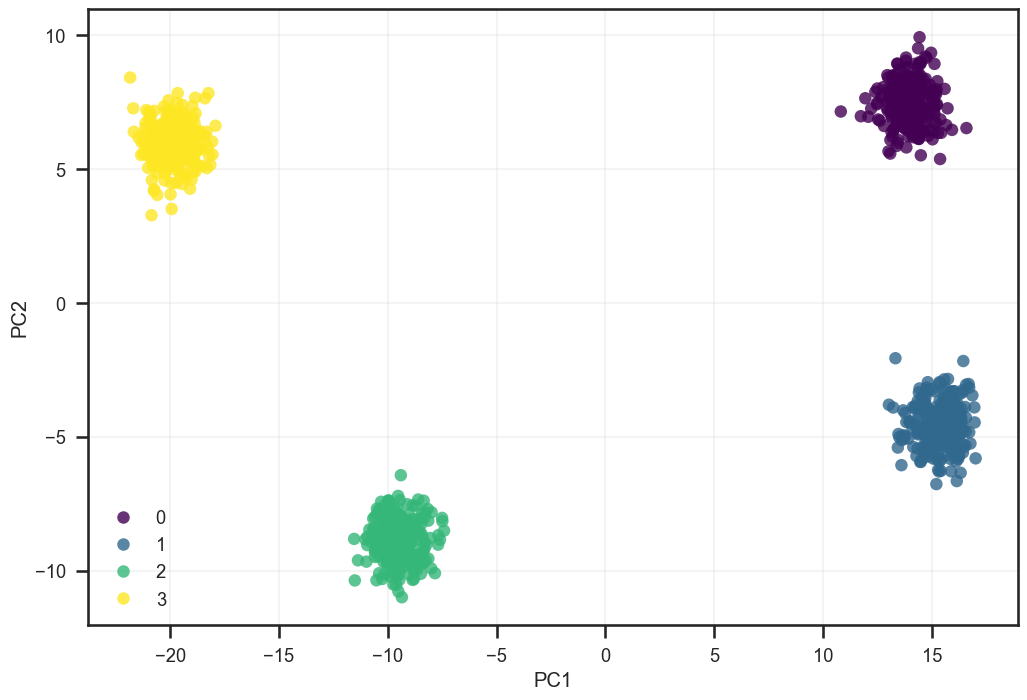

In [36]:
# Plot PCA with true label
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=y_dim, **scatter_kwargs);

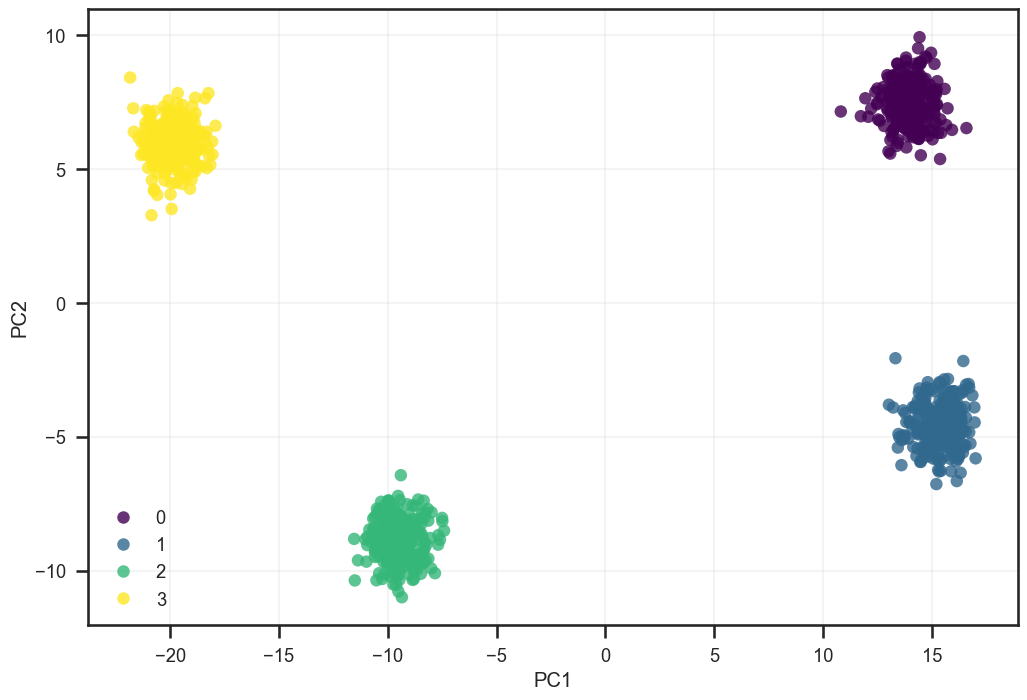

In [37]:
# Plot PCA with k-means label
labels = k_means(df_pca.iloc[:,:3], 4)[1]
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=y_dim, **scatter_kwargs);

In [38]:
pip install --upgrade nbformat


Note: you may need to restart the kernel to use updated packages.


In [39]:
# 3D PCA plot
px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color=labels, template='plotly_dark')

# Hierarchical clustering

**Tipos:**
- Agglomerative (bottom-up)
- Dissimilarity (top-down)

**Vantagens:**
- Fácil interpretação
- Não é necessário estabelecer a quantidade de grupos previamente

**Desvantagens:**
- Não escala bem com muitos dados
- Dendograma fica com visualização inviável para muitas amostras

In [40]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=80, n_features=2, centers=4, cluster_std=.6, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,-1.710205,8.159010
1,-0.397014,2.109227
2,-1.148252,8.216479
3,2.334665,-0.024083
4,-1.347961,3.713714


In [41]:
# Hierarchical clustering with sklearn
model = AgglomerativeClustering(n_clusters=4)
labels = model.fit_predict(X)

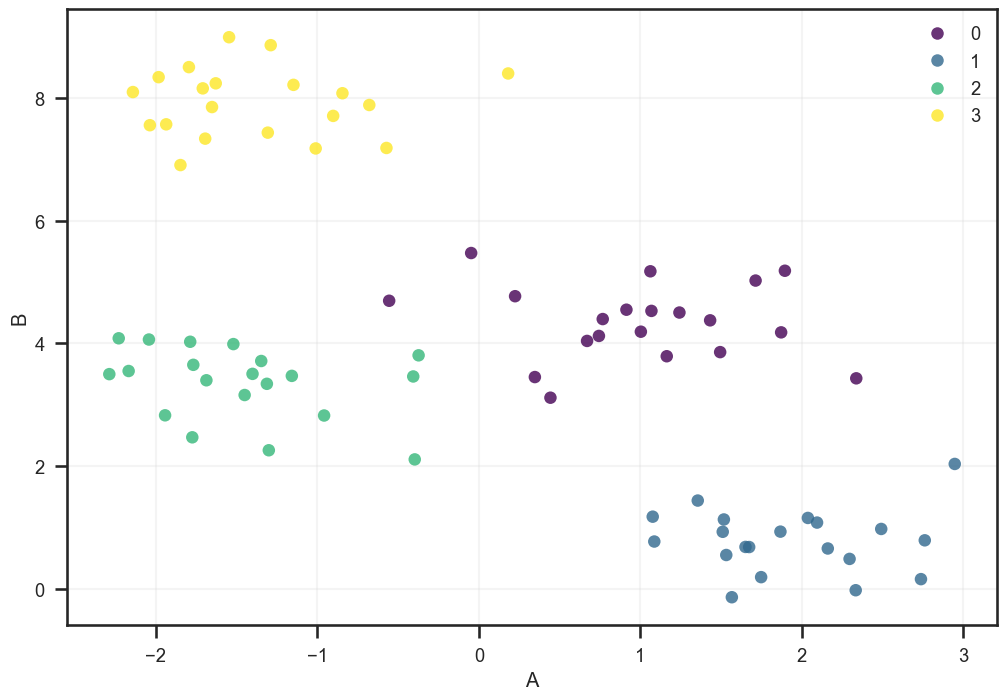

In [42]:
sns.scatterplot(data=df, x='A', y='B', hue=y, **scatter_kwargs);

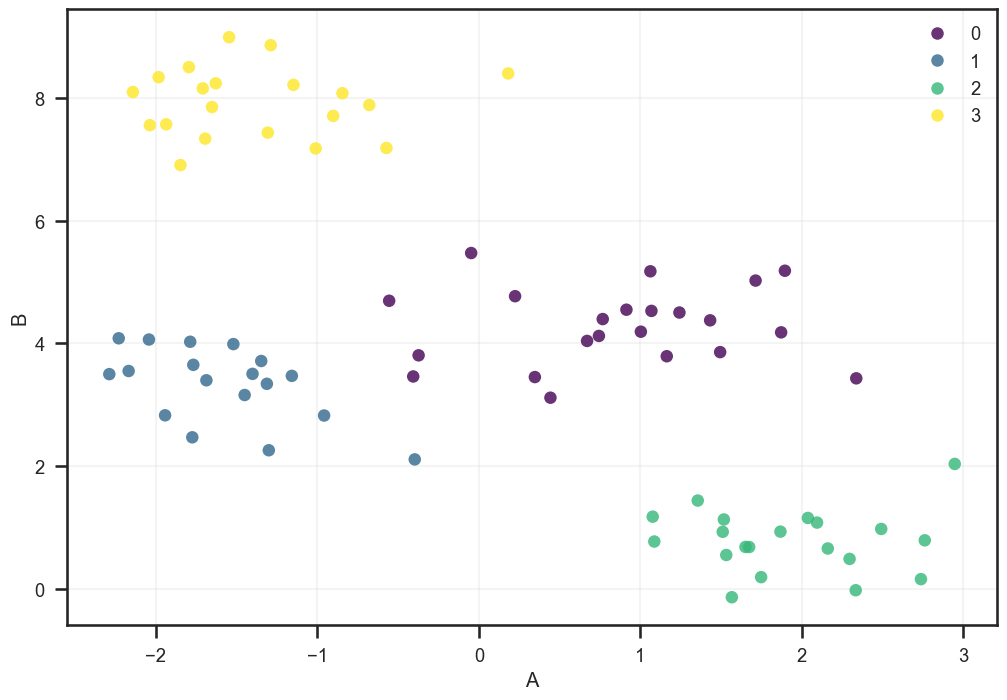

In [43]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs);

## Hierarchical clustering with scipy

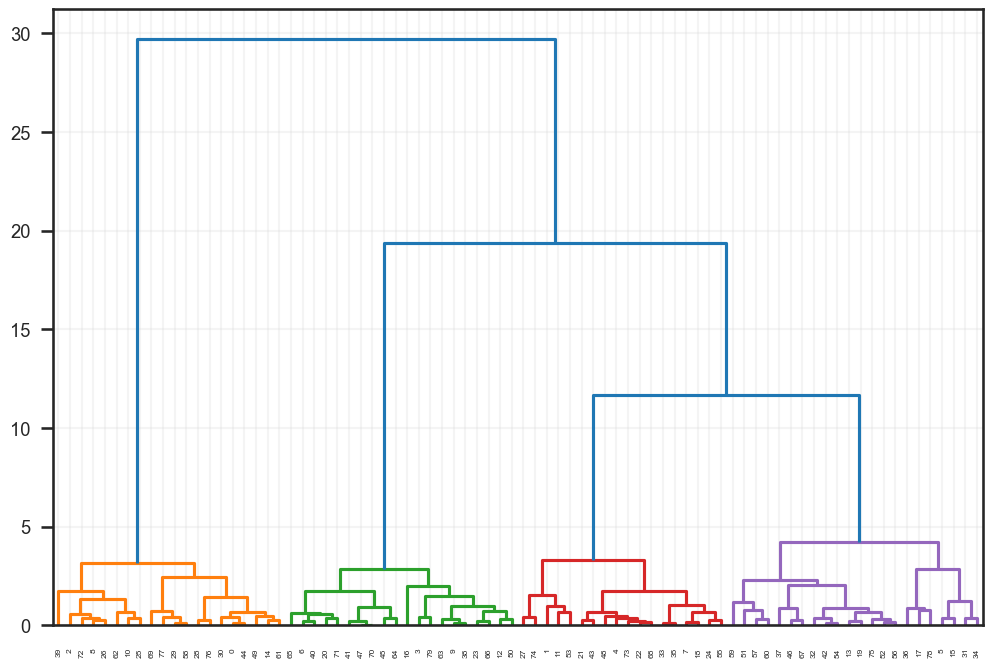

In [44]:
Z = linkage(df, method='ward')
dendrogram_dict = dendrogram(Z, color_threshold=10)
plt.show()

In [45]:
fcluster(Z, 4, criterion='maxclust')

array([1, 3, 1, 2, 3, 4, 2, 3, 1, 2, 1, 3, 2, 4, 1, 4, 2, 4, 3, 4, 2, 3,
       3, 2, 3, 1, 1, 3, 1, 1, 1, 4, 4, 3, 4, 3, 4, 4, 2, 1, 2, 2, 4, 3,
       1, 2, 4, 2, 3, 1, 2, 4, 4, 3, 4, 3, 4, 4, 1, 4, 4, 1, 1, 2, 2, 2,
       2, 4, 3, 1, 2, 2, 1, 3, 3, 4, 1, 1, 4, 2], dtype=int32)

In [46]:
@interact(method=['single','complete','centroid', 'ward'])
def plot_dendrogram(method):
  Z = linkage(df, method=method)
  dendrogram_dict = dendrogram(Z)
  plt.show()

interactive(children=(Dropdown(description='method', options=('single', 'complete', 'centroid', 'ward'), value…

# DBSCAN

**Vantagens:**
- Não necessita especificar a quantidade de clusters
- Detecta clusters de formatos variados (densos)
- Robusto aos outliers

**Desvantagens:**
- A qualidade do cluster depende muito métrica de distância
- Não funciona bem em clusters com densidades diferentes (OPTICS)

In [47]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(5E3), n_features=2, centers=4, cluster_std=.8, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,1.998996,1.535900
1,-2.788784,2.773154
2,-0.956255,3.630438
3,2.777738,-1.508286
4,0.982364,5.013279


In [48]:
# Train DBSCAN
model = DBSCAN()
labels = model.fit_predict(X)

In [49]:
# Train DBSCAN (function)
labels = dbscan(X)[1]

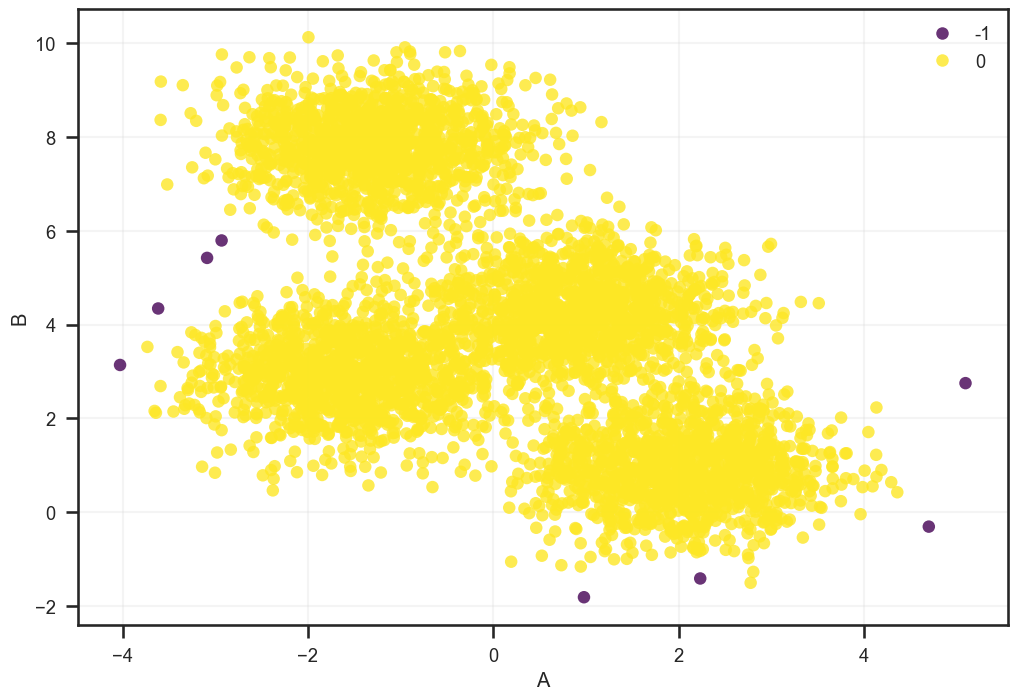

In [50]:
# Visualize output
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs);

In [51]:
@interact(eps=(0.01,1, 0.01), min_samples=(1,20))
def custom_dbscan(eps, min_samples):
  _, labels = dbscan(X, eps=eps, min_samples=min_samples)
  sns.scatterplot(data=df, x='A', y='B', hue=labels, palette='tab10')
  plt.show()

interactive(children=(FloatSlider(value=0.5, description='eps', max=1.0, min=0.01, step=0.01), IntSlider(value…

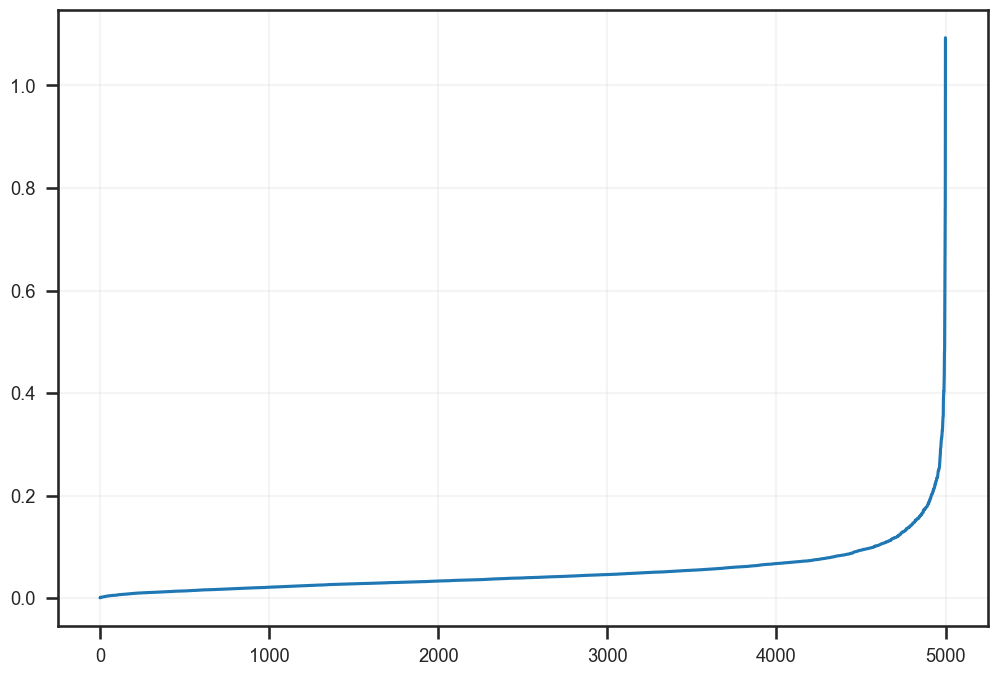

In [52]:
# https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc
from sklearn.neighbors import NearestNeighbors
nn_model = NearestNeighbors(n_neighbors=2).fit(X)
distances, indices = nn_model.kneighbors(X)
distances = np.sort(distances, axis=0)
plt.plot(distances[:,1])
plt.show()

# MeanShift

**Vantagens:**
- Possui apenas um parâmetro principal (bandwidth)
- Não necessita especificar a quantidade de clusters

**Desvantagens:**
- Computacionalmente custoso com grande volume de dados
- Não é possível especificar número de clusters

In [53]:
# Simulate clusters
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(1E3), n_features=2, centers=4, cluster_std=.8, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,-2.256086,7.858356
1,0.568548,3.953328
2,-2.602152,8.418937
3,-2.625338,2.063689
4,2.286564,1.227960


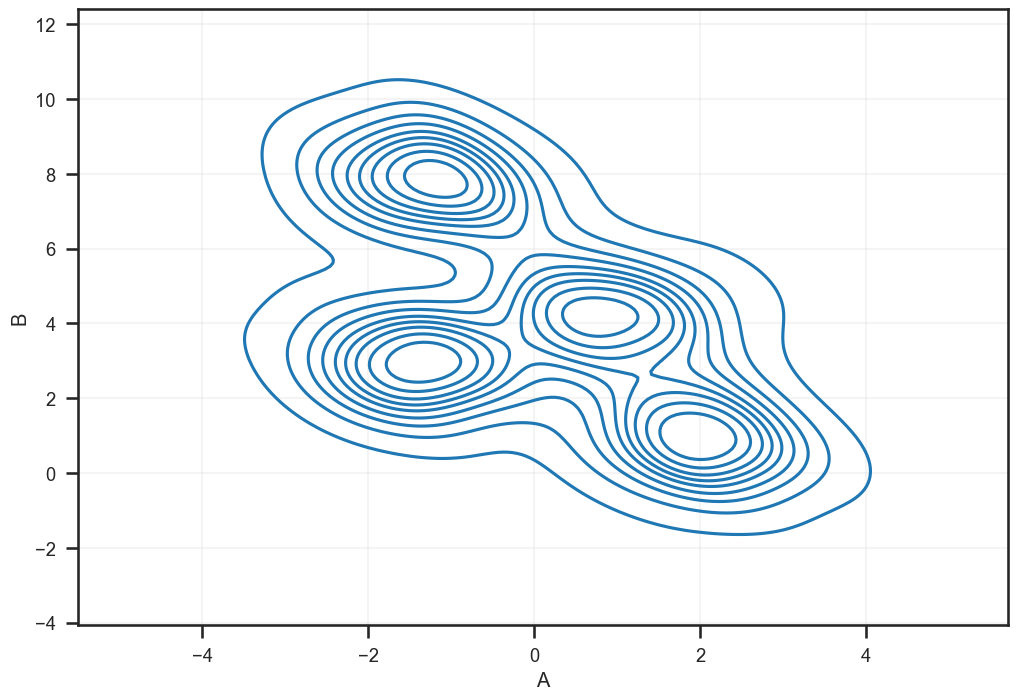

In [54]:
# Density plot
sns.kdeplot(data=df, x='A', y='B');

In [55]:
# Model & labels
model = MeanShift()
labels = model.fit_predict(X)

In [56]:
# Estimating bandwidth
estimate_bandwidth(X)

np.float64(2.822735629625506)

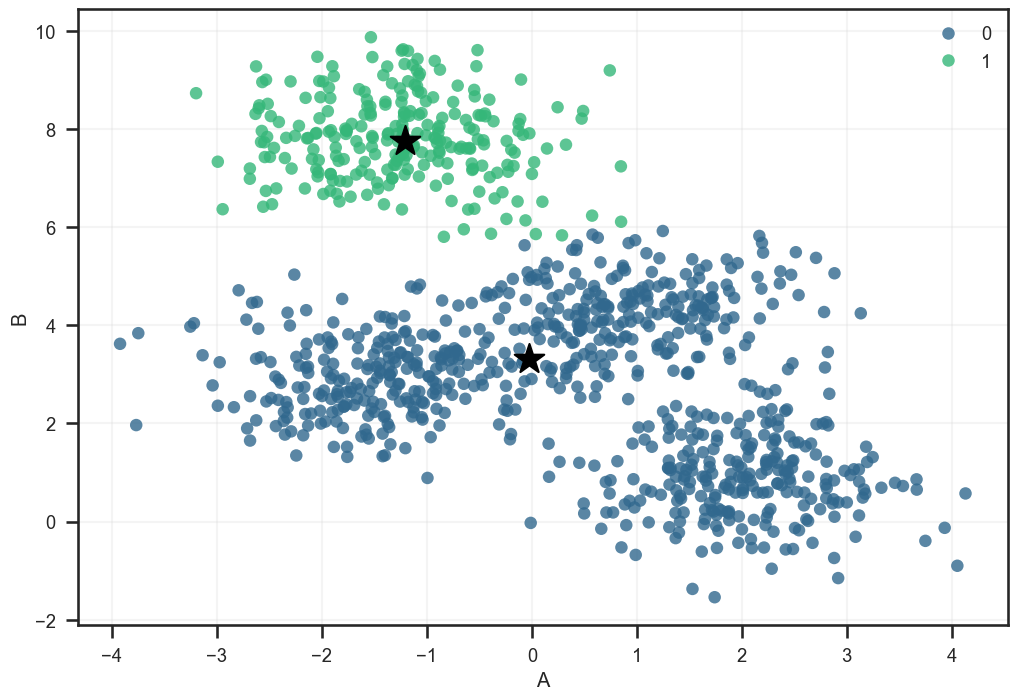

In [57]:
# Plot
ax = sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
ax.scatter(*model.cluster_centers_.T, marker='*', c='black', s=500)
plt.show()

In [58]:
@interact(bandwidth=(0.1, 3, 0.01))
def custom_meanshift(bandwidth):
  model = MeanShift(bandwidth=bandwidth, cluster_all=True)
  labels = model.fit_predict(X)
  ax = sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
  ax.scatter(*model.cluster_centers_.T, marker='*', c='black', s=500)
  plt.show()

interactive(children=(FloatSlider(value=1.55, description='bandwidth', max=3.0, min=0.1, step=0.01), Output())…

# Gaussian Mixture

In [59]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(1E3), n_features=2, centers=4, cluster_std=.8, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,-2.256086,7.858356
1,0.568548,3.953328
2,-2.602152,8.418937
3,-2.625338,2.063689
4,2.286564,1.227960


In [60]:
# Create model
model = GaussianMixture(n_components=4, covariance_type='spherical')
model.fit(X)

,n_components,4
,covariance_type,'spherical'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [61]:
# Model attributes
model.means_
model.covariances_
model.weights_

array([0.24963823, 0.25196805, 0.24984566, 0.24854806])

In [62]:
# Model BIC
model.bic(X)

np.float64(7426.425802608492)

In [63]:
# Predict labels
model.predict(X)[:5]

array([2, 1, 2, 3, 0])

In [64]:
# Predict labels' probability
model.predict_proba(X)[:5]

array([[1.84520950e-24, 4.46125372e-08, 9.99999953e-01, 2.08874832e-09],
       [8.41171761e-05, 9.83789133e-01, 3.01059928e-07, 1.61264487e-02],
       [4.27922712e-28, 6.61372416e-10, 9.99999999e-01, 2.32527962e-11],
       [3.62544037e-08, 8.09353136e-06, 1.70241414e-12, 9.99991870e-01],
       [9.99784337e-01, 2.14730008e-04, 9.88616547e-21, 9.33091376e-07]])

In [65]:
model.means_.T

array([[ 1.9950502 ,  0.91251225, -1.28890206, -1.47074945],
       [ 0.85843856,  4.26878154,  7.85197967,  2.9161483 ]])

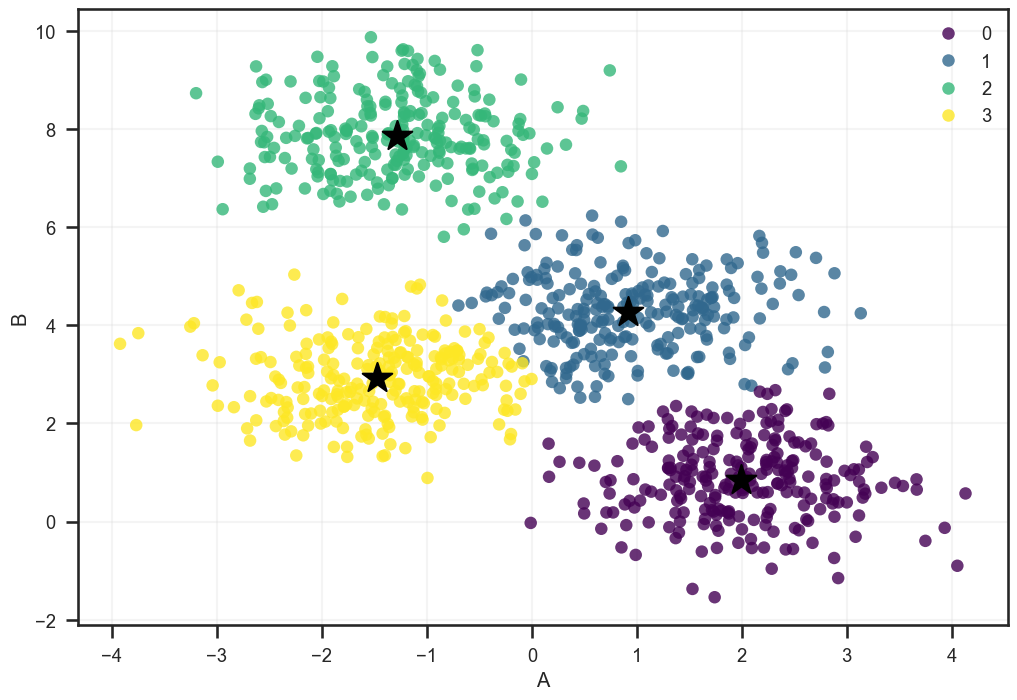

In [66]:
# Plot
labels = model.predict(X)
ax = sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
ax.scatter(*model.means_.T, marker='*', color='black', s=500);

In [67]:
# Select best model by covariance type and K (Practical Statistics for Data Scientists)
results = []
k_range = range(1,9)
covariance_types = ['full', 'tied', 'diag', 'spherical']

for n_components in k_range:
  for covariance_type in covariance_types:
    mclust = GaussianMixture(n_components=n_components, warm_start=True, covariance_type=covariance_type)
    mclust.fit(X)
    results.append({
      'bic': mclust.bic(X),
      'n_components': n_components,
      'covariance_type': covariance_type,
    })

results = pd.DataFrame(results)
results

,bic,n_components,covariance_type
0,8357.218909,1,full
1,8357.218909,1,tied
2,8679.299153,1,diag
3,8889.310673,1,spherical
4,7976.527656,2,full
5,8165.511057,2,tied
6,8050.082533,2,diag
7,8036.917677,2,spherical
8,7526.397339,3,full
9,7736.187733,3,tied


In [68]:
results.sort_values('bic').head()

,bic,n_components,covariance_type
13,7419.260030,4,tied
15,7426.425803,4,spherical
17,7439.038251,5,tied
14,7450.141842,4,diag
19,7455.654478,5,spherical


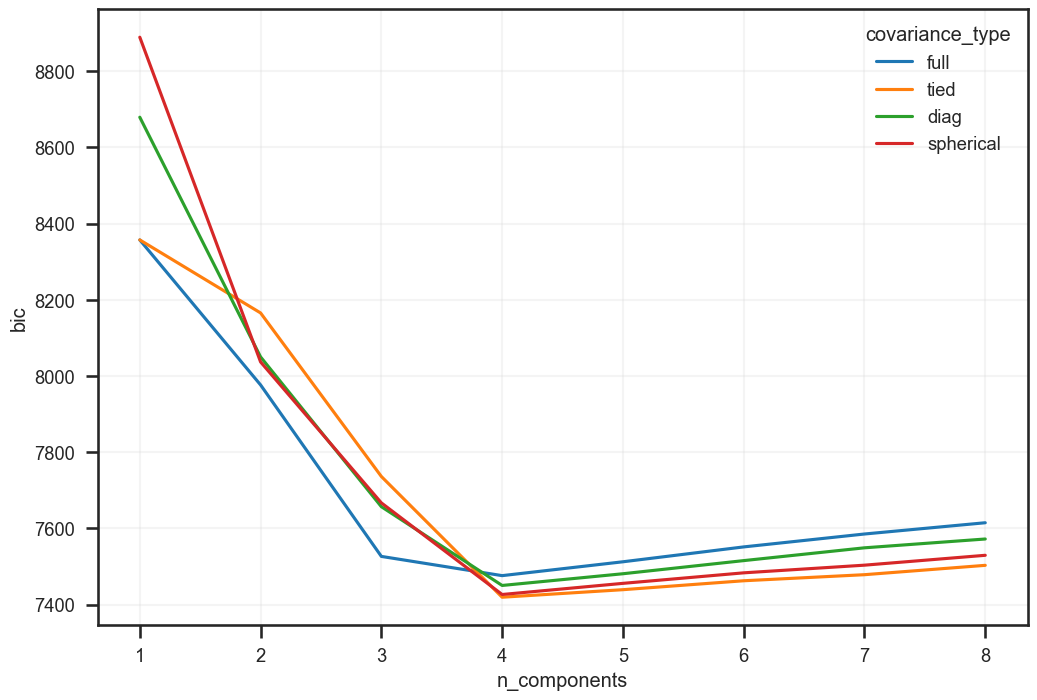

In [69]:
# Plot
sns.lineplot(data=results, x='n_components', y='bic', hue='covariance_type');

# Dataset with mix data

**Clustering com dados categóricos:**
- kmodes (apenas dados categóricos)
- kprototypes (dados numéricos e categóricos)
- hierarquical clustering com Glower' distance

**Análises de associação / redução de dimensionalidade:**
- Análise de correspondência simples (CA) - apenas dados categóricos com 2 variáveis
- Análise de correspondência múltipla (MCA) - apenas dados categóricos com 2 ou mais variáveis
- FAMD - dados mistos

## Dados categóricos

In [70]:
from yellowbrick.datasets import load_mushroom

In [71]:
# Load data
df_mushroom = load_mushroom()[0]
df_mushroom

,shape,surface,color
0,convex,smooth,yellow
1,bell,smooth,white
2,convex,scaly,white
3,convex,smooth,gray
4,convex,scaly,yellow
...,...,...,...
8118,knobbed,smooth,brown
8119,convex,smooth,brown
8120,flat,smooth,brown
8121,knobbed,scaly,brown


In [72]:
# Clustering with KModes
model = KModes(n_clusters=4)
labels = model.fit_predict(df_mushroom)
print(labels)
print(model.cost_)

[0 1 0 ... 1 0 0]
8851.0


In [73]:
# Avaliando modelo
custos = [KModes(n_clusters=K).fit(df_mushroom).cost_ for K in range(2,11)]
custos

[np.float64(11560.0),
 np.float64(10343.0),
 np.float64(8851.0),
 np.float64(8111.0),
 np.float64(7203.0),
 np.float64(6708.0),
 np.float64(6416.0),
 np.float64(6190.0),
 np.float64(5882.0)]

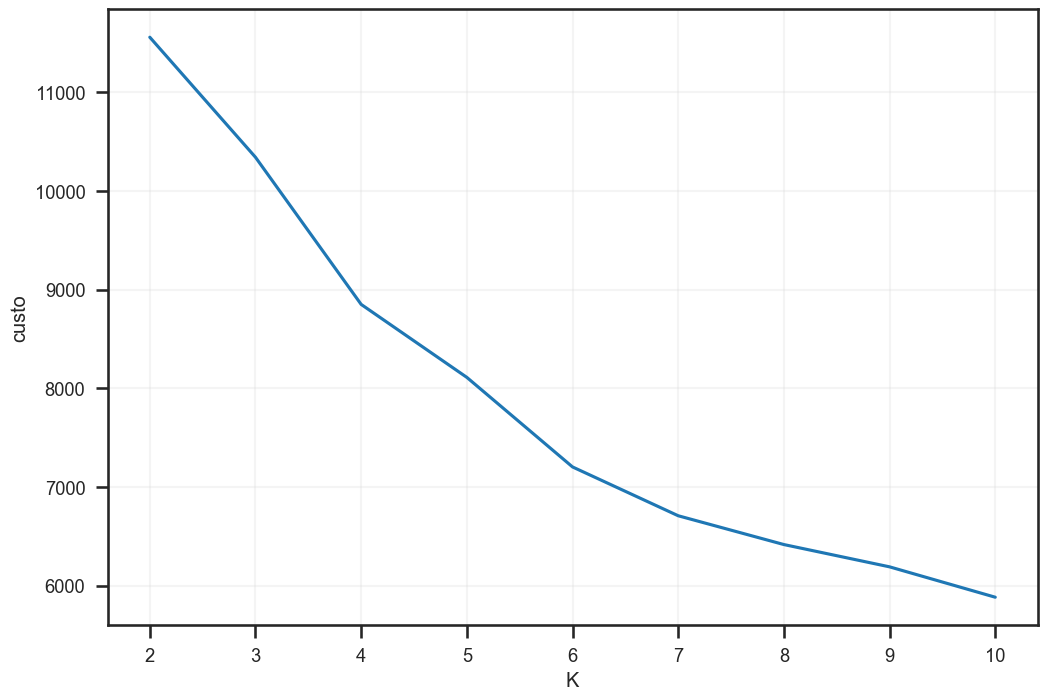

In [74]:
pd.Series(custos, index=range(2,11)).plot()
plt.xlabel('K')
plt.ylabel('custo')
plt.show()

## Dados mistos

Fonte e dicionário do dataset: [https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

In [75]:
df_diabetes = pd.read_csv('https://raw.githubusercontent.com/Ekeany/Clustering-Mixed-Data/main/data/heart.csv')
df_diabetes = df_diabetes.drop(columns='target')
df_diabetes

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [76]:
# Padroniza dados numéricos
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_diabetes[numerical_columns] = df_diabetes[numerical_columns].apply(scale)

In [77]:
# Define posições dos dados categóricos
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
categorical_idx = df_diabetes.columns.isin(categorical_columns).nonzero()[0].tolist()

In [78]:
# Modelagem com KPrototypes
model = KPrototypes()
model.fit(df_diabetes, categorical=categorical_idx)

,n_clusters,8
,max_iter,100
,num_dissim,<function euc...001A0D6DB0E00>
,cat_dissim,<function mat...001A0D6DB0C20>
,init,'Cao'
,n_init,10
,gamma,np.float64(0.5)
,verbose,0
,random_state,None
,n_jobs,1


In [79]:
model.predict(df_diabetes, categorical=categorical_idx)

array([3, 4, 4, 2, 2, 1, 0, 4, 1, 1, 1, 2, 2, 5, 1, 4, 2, 6, 4, 1, 1, 4,
       4, 1, 4, 1, 1, 7, 0, 4, 4, 7, 4, 2, 5, 4, 2, 1, 1, 0, 0, 2, 5, 2,
       2, 2, 4, 2, 7, 2, 2, 7, 5, 4, 1, 4, 4, 2, 4, 2, 7, 2, 4, 4, 1, 4,
       5, 4, 4, 7, 2, 4, 4, 2, 4, 2, 3, 1, 4, 7, 4, 2, 2, 1, 5, 0, 7, 4,
       7, 7, 4, 1, 4, 2, 4, 6, 0, 7, 2, 2, 4, 3, 1, 4, 4, 6, 1, 2, 4, 2,
       1, 1, 1, 4, 2, 4, 4, 5, 4, 2, 6, 2, 4, 2, 4, 4, 4, 1, 4, 7, 1, 2,
       2, 4, 2, 2, 7, 7, 5, 6, 2, 2, 4, 7, 6, 1, 4, 1, 4, 4, 3, 7, 1, 1,
       4, 7, 4, 4, 7, 2, 2, 2, 4, 4, 4, 6, 5, 3, 5, 3, 5, 4, 2, 3, 5, 5,
       7, 1, 5, 6, 0, 6, 2, 5, 3, 2, 5, 5, 4, 4, 0, 5, 5, 3, 3, 0, 3, 7,
       6, 7, 4, 5, 6, 1, 3, 2, 5, 3, 5, 1, 5, 3, 4, 0, 5, 0, 6, 0, 6, 2,
       0, 3, 1, 3, 5, 6, 6, 5, 1, 0, 4, 6, 0, 6, 6, 2, 2, 2, 7, 2, 6, 1,
       6, 6, 5, 2, 0, 6, 1, 6, 3, 2, 6, 7, 1, 2, 5, 5, 1, 3, 1, 4, 6, 7,
       5, 7, 0, 5, 5, 6, 2, 3, 6, 7, 5, 4, 6, 7, 2, 3, 0, 5, 5, 4, 5, 0,
       1, 1, 0, 5, 1, 3, 3, 1, 5, 3, 7, 6, 6, 5, 3,

In [80]:
# Avaliando modelo
model.cost_

np.float64(1057.8426698261662)

In [81]:
# Avaliando modelo
custos = [
    KPrototypes(K).fit(df_diabetes, categorical=categorical_idx).cost_
    for K in range(2,11)
    ]
custos

[np.float64(1566.240390895024),
 np.float64(1400.5235341919265),
 np.float64(1294.6676566448798),
 np.float64(1217.87362913125),
 np.float64(1155.1882234911477),
 np.float64(1090.856929483944),
 np.float64(1057.5957721998132),
 np.float64(1016.8728879733782),
 np.float64(982.7808463003365)]

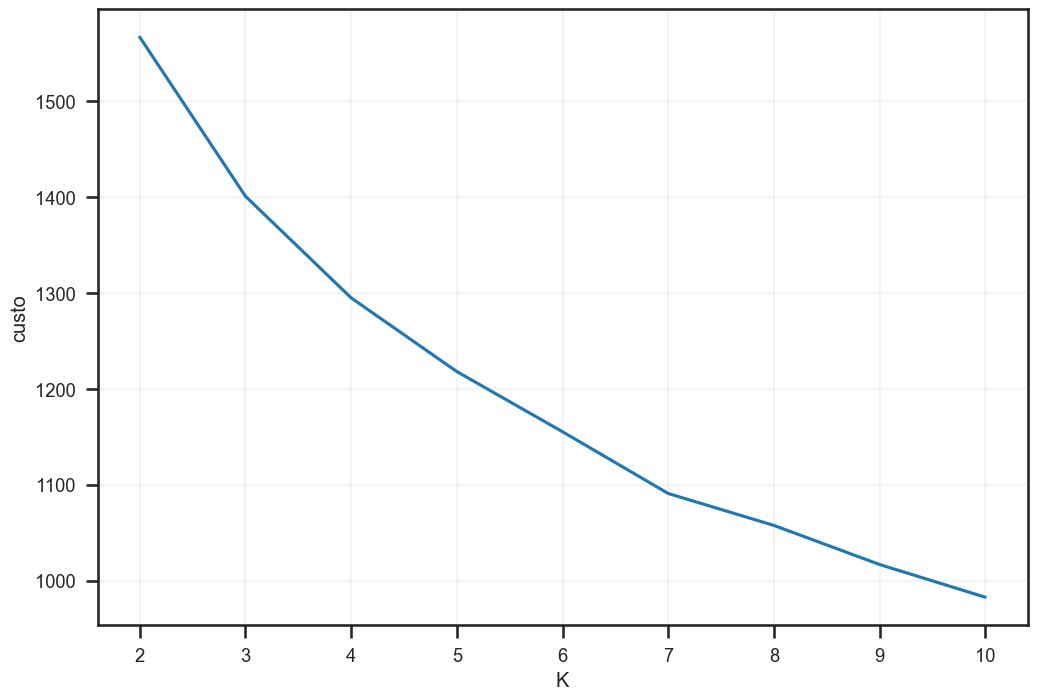

In [82]:
pd.Series(custos, index=range(2,11)).plot()
plt.xlabel('K')
plt.ylabel('custo')
plt.show()

# Wine dataset

## Carregando dados

In [83]:
df_wines,_ = datasets.load_wine(as_frame=True, return_X_y=True)
df_wines

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


## Data cleaning

In [84]:
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl